In [1]:
!pip install prophet yfinance matplotlib pandas


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Tirupati\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

C:\Users\Tirupati\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = yf.download("AAPL", start="2020-01-01", end="2026-01-01")
df.head()

C:\Users\Tirupati\AppData\Local\Temp\ipykernel_7712\1174533920.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2020-01-01", end="2026-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400520,72.460784,71.156682,71.409785,135480400
2020-01-03,71.696632,72.455950,71.472454,71.629138,146322800
2020-01-06,72.267944,72.306514,70.568518,70.819216,118387200
2020-01-07,71.928062,72.533103,71.708703,72.277586,108872000
2020-01-08,73.085106,73.386423,71.631552,71.631552,132079200


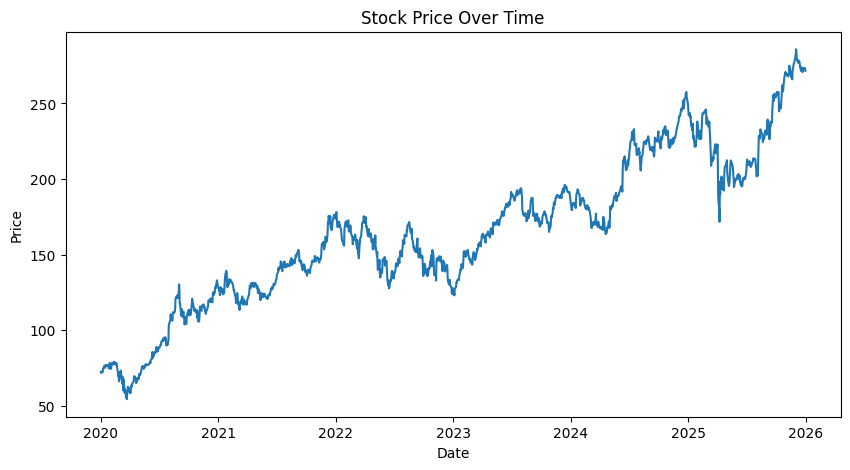

In [3]:
plt.figure(figsize=(10,5))
plt.plot(df['Close'])
plt.title("Stock Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [6]:
print(df.columns)

Index(['index', 'ds', 'y'], dtype='object', name='Price')


In [7]:
# Remove extra column
df = df[['ds', 'y']]

# Final check
print(df.head())
print(df.dtypes)

Price         ds          y
0     2020-01-02  72.400520
1     2020-01-03  71.696632
2     2020-01-06  72.267944
3     2020-01-07  71.928062
4     2020-01-08  73.085106
Price
ds    datetime64[ns]
y            float64
dtype: object


In [8]:
model = Prophet()

In [9]:
model.fit(df)

12:47:29 - cmdstanpy - INFO - Chain [1] start processing
12:47:30 - cmdstanpy - INFO - Chain [1] done processing


In [10]:
future = model.make_future_dataframe(periods=60)
future.tail()

,ds
1563,2026-02-25
1564,2026-02-26
1565,2026-02-27
1566,2026-02-28
1567,2026-03-01


In [11]:
forecast = model.predict(future)

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
1563,2026-02-25,248.699930,235.857264,261.733896
1564,2026-02-26,247.792261,235.187182,260.747021
1565,2026-02-27,247.307761,234.208720,259.927931
1566,2026-02-28,250.785360,238.784904,264.039797
1567,2026-03-01,250.105951,236.764237,263.483138


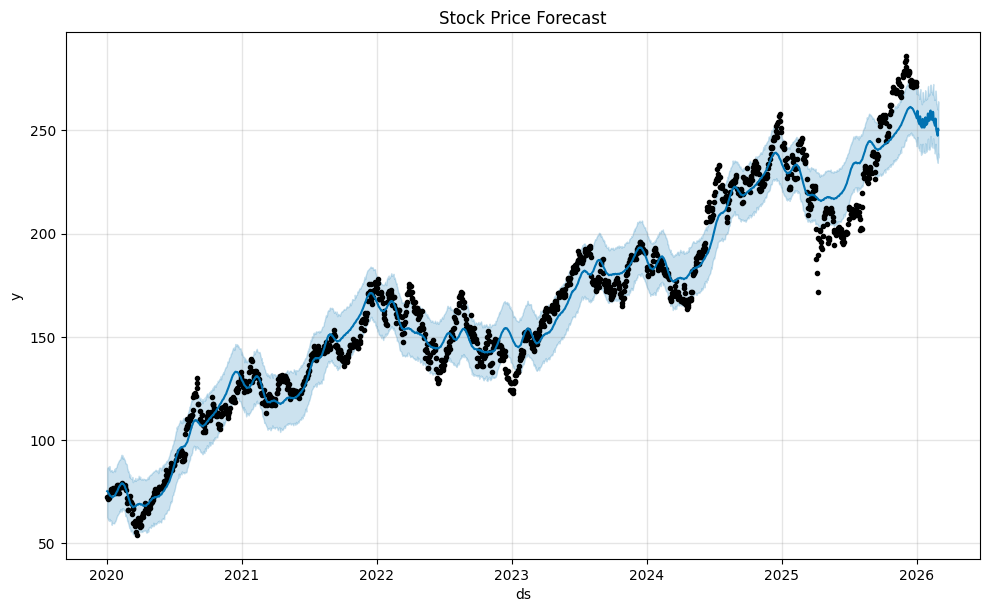

In [12]:
model.plot(forecast)
plt.title("Stock Price Forecast")
plt.show()

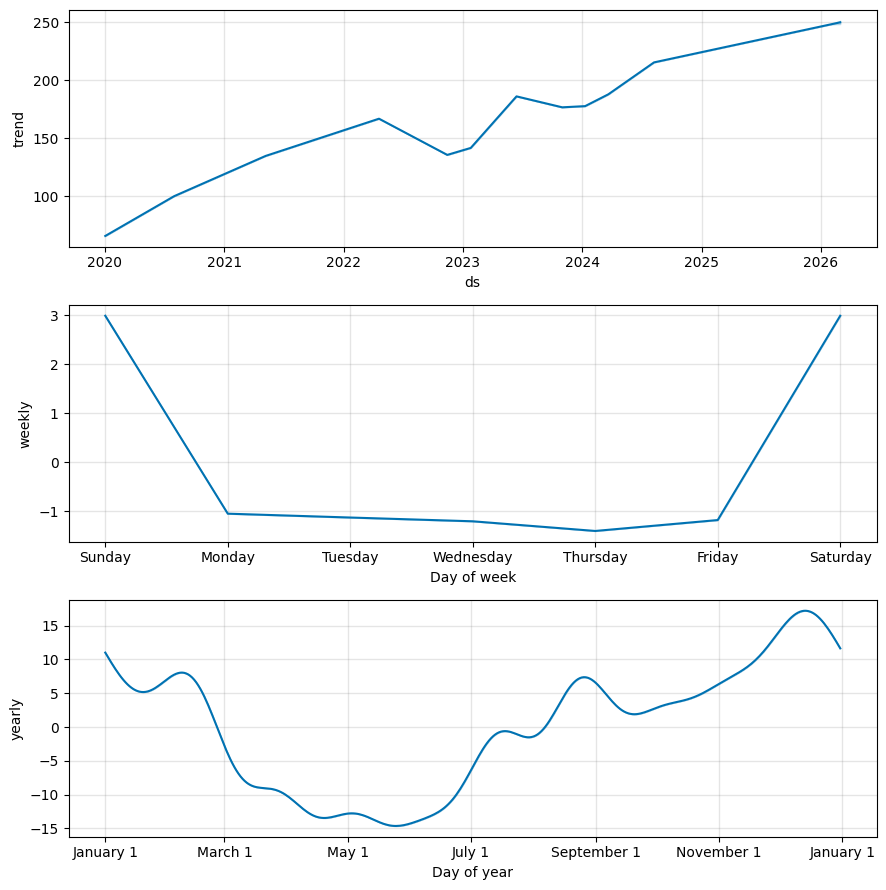

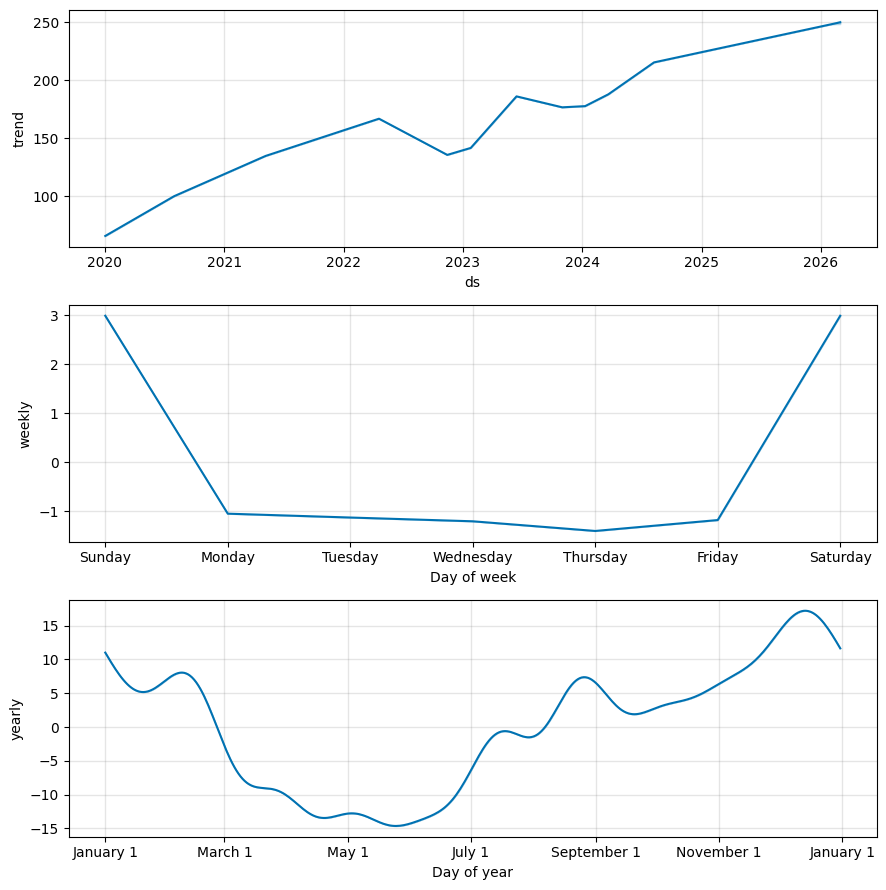

In [13]:
model.plot_components(forecast)

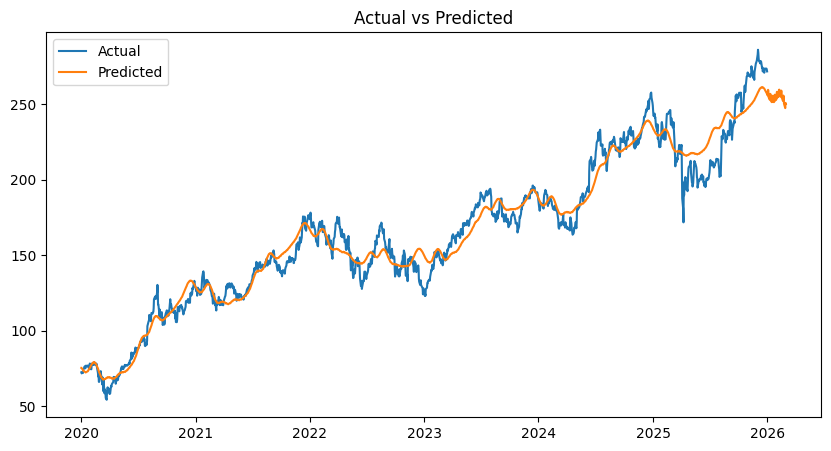

In [14]:
plt.figure(figsize=(10,5))

plt.plot(df['ds'], df['y'], label='Actual')
plt.plot(forecast['ds'], forecast['yhat'], label='Predicted')

plt.legend()
plt.title("Actual vs Predicted")
plt.show()

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Merge actual and predicted values (only for existing dates)
df_merged = pd.merge(df, forecast[['ds', 'yhat']], on='ds')

# Calculate metrics
mae = mean_absolute_error(df_merged['y'], df_merged['yhat'])
rmse = np.sqrt(mean_squared_error(df_merged['y'], df_merged['yhat']))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 7.642173032721819
RMSE: 9.909557599448487


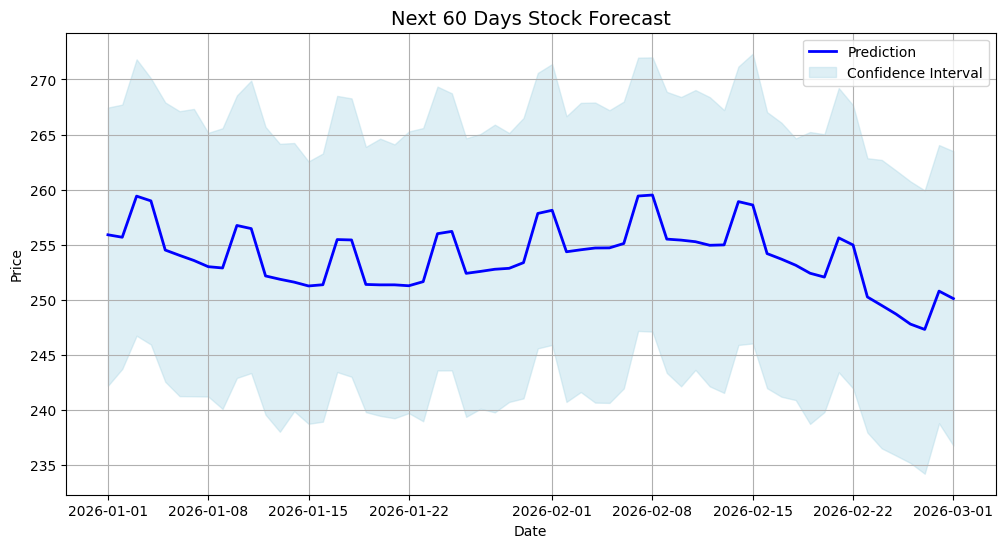

In [17]:
plt.figure(figsize=(12,6))

# Prediction line
plt.plot(future_only['ds'], future_only['yhat'], color='blue', linewidth=2, label='Prediction')

# Confidence interval
plt.fill_between(
    future_only['ds'],
    future_only['yhat_lower'],
    future_only['yhat_upper'],
    color='lightblue',
    alpha=0.4,
    label='Confidence Interval'
)

plt.title("Next 60 Days Stock Forecast", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.show()

In [19]:
model = Prophet(
    daily_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.5,   # trend flexibility ↑
    seasonality_prior_scale=10     # seasonality strength ↑
)

# Add monthly seasonality (important 🔥)
model.add_seasonality(
    name='monthly',
    period=30.5,
    fourier_order=5
)

# Train again
model.fit(df)

12:58:26 - cmdstanpy - INFO - Chain [1] start processing
12:58:27 - cmdstanpy - INFO - Chain [1] done processing


In [20]:
future = model.make_future_dataframe(periods=60)
forecast = model.predict(future)

# Future only
future_only = forecast[forecast['ds'] > df['ds'].max()]

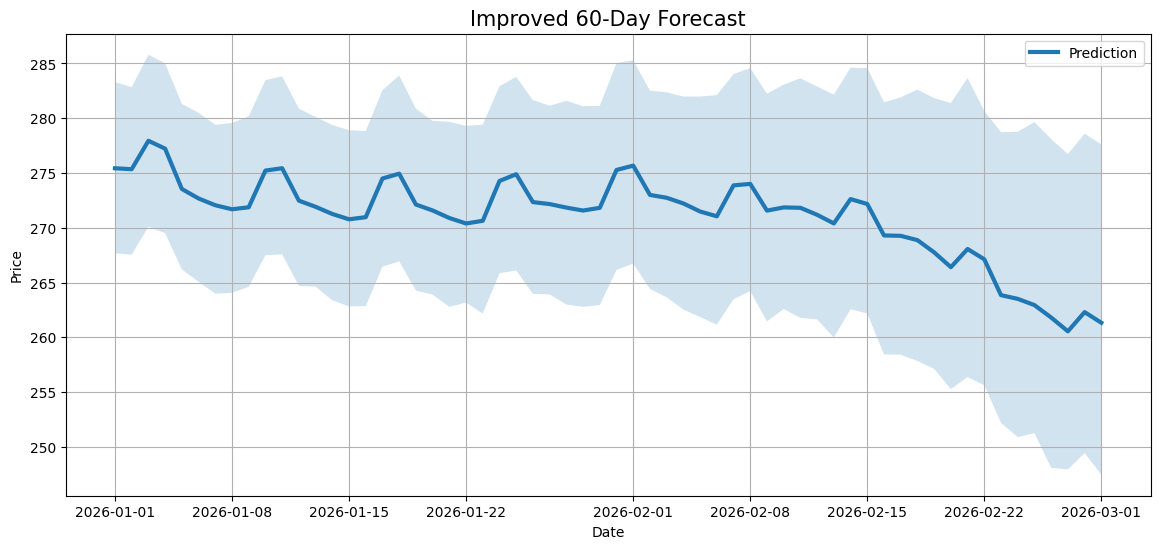

In [21]:
plt.figure(figsize=(14,6))

plt.plot(future_only['ds'], future_only['yhat'], 
         linewidth=3, label='Prediction')

plt.fill_between(
    future_only['ds'],
    future_only['yhat_lower'],
    future_only['yhat_upper'],
    alpha=0.2
)

plt.title("Improved 60-Day Forecast", fontsize=15)
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.show()

In [22]:
df_merged = pd.merge(df, forecast[['ds','yhat']], on='ds')

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(df_merged['y'], df_merged['yhat'])
rmse = np.sqrt(mean_squared_error(df_merged['y'], df_merged['yhat']))

print("Improved MAE:", mae)
print("Improved RMSE:", rmse)

Improved MAE: 4.698543070726768
Improved RMSE: 6.072339513943207


In [25]:
start = future_only['yhat'].iloc[0]
end = future_only['yhat'].iloc[-1]

print("Start Price:", start)
print("End Price:", end)

if end > start:
    print(" Uptrend expected")
elif end < start:
    print(" Downtrend expected")
else:
    print(" Sideways trend")

Start Price: 275.4310511999167
End Price: 261.32990220936335
 Downtrend expected


In [24]:
change = ((end - start) / start) * 100
print(f"Expected Change: {change:.2f}%")

Expected Change: -5.12%
